1. Understand the dataset

First, import the libraries we need.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

What these libraries do
Pandas → used to load, clean and analyse tables.
NumPy → useful for numerical calculations.
Matplotlib → used to create charts.

2. Load the Excel file

Your file is an Excel workbook, so we use read_excel()

In [7]:
df = pd.read_excel("/content/comapany data.xlsx")

df means DataFrame. Think of a DataFrame as a table in Excel.

To see the first five rows:

In [8]:
df.head()

,Company Reference,Company Type,Postcode,CompanyCategory,CompanyStatus,CountryOfOrigin,Company Closed Date,IncorporationDate,AccountLastMadeDate,2022 Turnover,2023 Turnover,2024 Turnover,2025 Turnover,2026 Turnover
0,Summary-Construction,Construction,All,All,NaN,NaN,NaT,NaT,NaT,3.760266e+09,4.177156e+09,4.623585e+09,4.805016e+09,4.758252e+09
1,Summary-Consultancy,Consultancy,All,All,NaN,NaN,NaT,NaT,NaT,4.149473e+09,3.280256e+09,5.162926e+09,5.400981e+09,5.403103e+09
2,Summary-Education,Education,All,All,NaN,NaN,NaT,NaT,NaT,2.479188e+08,2.476784e+08,2.464316e+08,2.163052e+08,1.829862e+08
3,Summary-Farming,Farming,All,All,NaN,NaN,NaT,NaT,NaT,2.189388e+08,2.059912e+08,2.037192e+08,2.200120e+08,2.053459e+08
4,Summary-Healthcare,Healthcare,All,All,NaN,NaN,NaT,NaT,NaT,5.469332e+08,6.657067e+08,8.184443e+08,9.425471e+08,1.037401e+09


3. Find out how big the dataset is

In [9]:
df.shape

(50520, 14)

For this dataset, there are 50,520 rows including the summary rows.

To see the number of columns:

In [10]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 50520
Columns: 14


Why is this important?

Before cleaning, you need to know how much data you are working with.

In [11]:
df.columns

Index(['Company Reference', 'Company Type', 'Postcode', 'CompanyCategory',
       'CompanyStatus', 'CountryOfOrigin', 'Company Closed Date',
       'IncorporationDate', 'AccountLastMadeDate', '2022 Turnover',
       '2023 Turnover', '2024 Turnover', '2025 Turnover', '2026 Turnover'],
      dtype='object')

This tells you what information is available.

For example, you will have columns relating to:

Company Reference
Company Type
Incorporation Date
Postcode
Turnover
Company status
Geographic information

5. Check the data types

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50520 entries, 0 to 50519
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Company Reference    50520 non-null  object        
 1   Company Type         50495 non-null  object        
 2   Postcode             49884 non-null  object        
 3   CompanyCategory      50520 non-null  object        
 4   CompanyStatus        50510 non-null  object        
 5   CountryOfOrigin      50510 non-null  object        
 6   Company Closed Date  918 non-null    datetime64[ns]
 7   IncorporationDate    50510 non-null  datetime64[ns]
 8   AccountLastMadeDate  37315 non-null  datetime64[ns]
 9   2022 Turnover        28981 non-null  float64       
 10  2023 Turnover        32321 non-null  float64       
 11  2024 Turnover        35880 non-null  float64       
 12  2025 Turnover        37188 non-null  float64       
 13  2026 Turnover        37171 non-

This is one of the most important commands when cleaning data.

It tells you whether a column is:

object → usually text
int64 → whole numbers
float64 → decimal numbers
datetime64 → dates

For example, IncorporationDate should ideally be a date, not ordinary text.

6. Check for missing values

In [13]:
df.isnull().sum()

,0
Company Reference,0
Company Type,25
Postcode,636
CompanyCategory,0
CompanyStatus,10
CountryOfOrigin,10
Company Closed Date,49602
IncorporationDate,10
AccountLastMadeDate,13205
2022 Turnover,21539


Why do this?

Missing values can affect calculations.

For example, if 20% of turnover values are missing, calculating the average without understanding the missing data could produce misleading results.

7. Check for duplicate records

In [14]:
df.duplicated().sum()

np.int64(9)

Check the company types

Before analysing sectors, let's see what sectors/business types exist.
This is useful because the assignment asks you to compare different sectors.

In [15]:
df["Company Type"].value_counts()

,count
Company Type,
Other,33036
Retail,4776
Consultancy,3931
Manufacturing,2090
Construction,2059
Transport and Logistics,1161
Healthcare,1128
Maintenance and Repair,847
Education,827


9. Identify the summary rows

This particular dataset contains rows beginning with "Summary-".

First, find them:

In [16]:
df[df["Company Reference"].astype(str).str.startswith("Summary-")]

,Company Reference,Company Type,Postcode,CompanyCategory,CompanyStatus,CountryOfOrigin,Company Closed Date,IncorporationDate,AccountLastMadeDate,2022 Turnover,2023 Turnover,2024 Turnover,2025 Turnover,2026 Turnover
0,Summary-Construction,Construction,All,All,NaN,NaN,NaT,NaT,NaT,3.760266e+09,4.177156e+09,4.623585e+09,4.805016e+09,4.758252e+09
1,Summary-Consultancy,Consultancy,All,All,NaN,NaN,NaT,NaT,NaT,4.149473e+09,3.280256e+09,5.162926e+09,5.400981e+09,5.403103e+09
2,Summary-Education,Education,All,All,NaN,NaN,NaT,NaT,NaT,2.479188e+08,2.476784e+08,2.464316e+08,2.163052e+08,1.829862e+08
3,Summary-Farming,Farming,All,All,NaN,NaN,NaT,NaT,NaT,2.189388e+08,2.059912e+08,2.037192e+08,2.200120e+08,2.053459e+08
4,Summary-Healthcare,Healthcare,All,All,NaN,NaN,NaT,NaT,NaT,5.469332e+08,6.657067e+08,8.184443e+08,9.425471e+08,1.037401e+09
5,Summary-Maintenance and Repair,Maintenance and Repair,All,All,NaN,NaN,NaT,NaT,NaT,3.972423e+08,4.029634e+08,3.804402e+08,3.309074e+08,2.712313e+08
6,Summary-Manufacturing,Manufacturing,All,All,NaN,NaN,NaT,NaT,NaT,1.350855e+09,1.068127e+09,1.682055e+09,1.741541e+09,1.748434e+09
7,Summary-Other,Other,All,All,NaN,NaN,NaT,NaT,NaT,9.473820e+09,6.550253e+09,7.291541e+09,9.680920e+09,1.127710e+10
8,Summary-Retail,Retail,All,All,NaN,NaN,NaT,NaT,NaT,1.605416e+09,2.114201e+09,1.937051e+09,2.376800e+09,1.912718e+09
9,Summary-Transport and Logistics,Transport and Logistics,All,All,NaN,NaN,NaT,NaT,NaT,6.803467e+08,8.073900e+08,8.861837e+08,9.230841e+08,9.208353e+08


Count them:

In [17]:
df["Company Reference"].astype(str).str.startswith("Summary-").sum()

np.int64(10)

There are 10 summary rows.

Why remove them?

These rows contain pre-calculated summary information rather than individual companies.

If we leave them in, we could accidentally count the same information twice.

10. Remove the summary rows

Create a clean dataset:

In [18]:
df_clean = df[
    ~df["Company Reference"]
    .astype(str)
    .str.startswith("Summary-", na=False)
].copy()

Check the new size:

In [19]:
df_clean.shape

(50510, 14)

50,510 actual company records.

11. Convert the incorporation date

Check the current data type:

In [ ]:
df_clean["IncorporationDate"].dtype

Convert it to a proper date:

In [20]:
df_clean["IncorporationDate"] = pd.to_datetime(
    df_clean["IncorporationDate"],
    errors="coerce"
)

What does errors="coerce" mean?

If Python finds something that isn't a valid date, it converts it to a missing value (NaT) instead of stopping the program.

12. Check the dates again

In [22]:
df_clean["IncorporationDate"].dtype

dtype('<M8[ns]')

13. Create an incorporation year column

We can extract the year from the date.

In [23]:
df_clean["incorporation_year"] = (
    df_clean["IncorporationDate"].dt.year
)

In [24]:
df_clean[["IncorporationDate", "incorporation_year"]].head()

,IncorporationDate,incorporation_year
10,2000-11-17,2000
11,2020-05-04,2020
12,2015-11-30,2015
13,2017-05-26,2017
14,2019-01-08,2019


14. Create an incorporation month column

We also need the month because question 2 asks:

What is the most common month for a business to incorporate?

In [25]:
df_clean["incorporation_month"] = (
    df_clean["IncorporationDate"].dt.month
)

Now Python stores January as 1, February as 2, etc.

15. Get the month name

Numbers are not very user-friendly, so create the actual month name.

In [26]:
df_clean["incorporation_month_name"] = (
    df_clean["IncorporationDate"].dt.month_name()
)

check

In [27]:
df_clean[
    ["IncorporationDate", "incorporation_month_name"]
].head()

,IncorporationDate,incorporation_month_name
10,2000-11-17,November
11,2020-05-04,May
12,2015-11-30,November
13,2017-05-26,May
14,2019-01-08,January


Now we start answering Question 1.
Analyse the number of companies by sector

In [28]:
sector_count = (
    df_clean["Company Type"]
    .value_counts()
)

Display it:

In [29]:
print(sector_count)

Company Type
Other                      33035
Retail                      4775
Consultancy                 3930
Manufacturing               2089
Construction                2058
Transport and Logistics     1160
Healthcare                  1127
Maintenance and Repair       846
Education                    826
Farming                      639
Name: count, dtype: int64


What are we finding?

We are asking:

Which sector has the largest number of companies?

In this dataset, Other has the largest number of companies.

. Calculate average turnover by sector

Let's use 2026 turnover.

In [30]:
average_turnover = (
    df_clean
    .groupby("Company Type")["2026 Turnover"]
    .mean()
    .sort_values(ascending=False)
)

display

In [31]:
print(average_turnover)

Company Type
Construction               3.149075e+06
Consultancy                1.861214e+06
Healthcare                 1.288697e+06
Manufacturing              1.143515e+06
Transport and Logistics    1.085891e+06
Retail                     5.455555e+05
Other                      4.626121e+05
Farming                    4.583613e+05
Maintenance and Repair     4.468390e+05
Education                  2.994864e+05
Name: 2026 Turnover, dtype: float64


What does groupby() mean?

Imagine putting all companies into separate boxes:

Construction → companies
Consultancy → companies
Healthcare → companies
Retail → companies
Other → companies

Then Python calculates the average turnover inside each box.

Find the sector with the highest average turnover

In [32]:
highest_turnover_sector = average_turnover.idxmax()
highest_turnover = average_turnover.max()

print("Sector:", highest_turnover_sector)
print("Average turnover:", highest_turnover)

Sector: Construction
Average turnover: 3149075.078755791


The result is:

Construction has the highest average turnover per company.

. Compare sector size and average turnover

Create one table containing both measurements:

In [33]:
sector_analysis = pd.DataFrame({
    "Company Count": sector_count,
    "Average 2026 Turnover": average_turnover
})

sector_analysis

,Company Count,Average 2026 Turnover
Company Type,,
Construction,2058,3.149075e+06
Consultancy,3930,1.861214e+06
Education,826,2.994864e+05
Farming,639,4.583613e+05
Healthcare,1127,1.288697e+06
Maintenance and Repair,846,4.468390e+05
Manufacturing,2089,1.143515e+06
Other,33035,4.626121e+05
Retail,4775,5.455555e+05


This gives you a much better comparison.

Interpretation

The important finding is:

Construction has the highest average turnover per company, while Other has the largest number of companies.

This demonstrates that having more companies does not necessarily mean having the highest turnover per company.

**QUESTION 2**
Find the most common incorporation month

In [34]:
monthly_registrations = (
    df_clean["incorporation_month_name"]
    .value_counts()
)

Display Result

In [35]:
print(monthly_registrations)

incorporation_month_name
January      5103
November     4657
September    4566
April        4482
July         4446
October      4343
May          4275
February     4267
June         4209
March        4015
December     3307
August       2840
Name: count, dtype: int64


Find the highest

In [36]:
most_common_month = monthly_registrations.idxmax()
number_of_companies = monthly_registrations.max()

print("Most common month:", most_common_month)
print("Number of companies:", number_of_companies)

Most common month: January
Number of companies: 5103


Result

January is the most common incorporation month.

** Check whether this pattern is consistent across sectors**

This is important because the question doesn't only ask about the overall month.

We want:

What is the most common month within each sector?

In [38]:
sector_month = pd.crosstab(
    df_clean["Company Type"],
    df_clean["incorporation_month_name"]
)

Find the highest month for each sector:

In [39]:
sector_top_month = sector_month.idxmax(axis=1)

print(sector_top_month)

Company Type
Construction                November
Consultancy                  January
Education                    January
Farming                        April
Healthcare                 September
Maintenance and Repair          July
Manufacturing                  April
Other                        January
Retail                       January
Transport and Logistics     November
dtype: object


Finding

January is the overall leader, but the pattern varies by sector.

That is a stronger conclusion than simply saying "January is the most common."

**Analyse turnover over time**

We have five turnover columns:

In [40]:
turnover_columns = [
    "2022 Turnover",
    "2023 Turnover",
    "2024 Turnover",
    "2025 Turnover",
    "2026 Turnover"
]

Calculate total turnover each year:

In [41]:
total_turnover = df_clean[turnover_columns].sum()

print(total_turnover)

2022 Turnover    2.244148e+10
2023 Turnover    1.952710e+10
2024 Turnover    2.324220e+10
2025 Turnover    2.664900e+10
2026 Turnover    2.772897e+10
dtype: float64


This answers:

Is turnover increasing or decreasing over time?

**Calculate average turnover over time**

Instead of total turnover, we can look at the average company turnover.

In [42]:
average_turnover_year = (
    df_clean[turnover_columns].mean()
)

print(average_turnover_year)

2022 Turnover    774618.810051
2023 Turnover    604348.417164
2024 Turnover    647956.462420
2025 Turnover    716794.761230
2026 Turnover    746184.642582
dtype: float64


**Why use both total and average?**

Because they answer different questions.

Total turnover:

How much turnover does the entire dataset generate?

Average turnover:

How much turnover does a typical company generate on average?

**Calculate year-on-year growth**

This is important for Question 3.

First calculate average turnover by sector and year:

In [56]:
sector_year_turnover = (
    df_clean
    .groupby("Company Type")[turnover_columns]
    .mean()
)

Then calculate percentage change

In [57]:
sector_yoy = sector_year_turnover.pct_change(axis=1) * 100

In [53]:
print(sector_yoy)

                         2022 Turnover  2023 Turnover  2024 Turnover  \
Company Type                                                           
Construction                       NaN            NaN            NaN   
Consultancy                 -41.328249     -58.715396     -41.378888   
Education                   -71.715487     -63.806293     -77.561596   
Farming                      -9.965230      -1.366675       8.753877   
Healthcare                   84.260570     105.063295     133.878451   
Maintenance and Repair       -3.825673     -21.070329     -38.473251   
Manufacturing                34.766988       5.828688      75.054998   
Other                       -55.912992     -61.280556     -72.829734   
Retail                       17.688962     123.317118      84.797921   
Transport and Logistics      75.695660      56.651357      88.742978   

                         2025 Turnover  2026 Turnover  
Company Type                                           
Construction           

Each number tells us how much average turnover changed compared with the previous year.

**Measure consistency**

The question asks:

Which sector shows the most consistent change in turnover year-on-year?

We need a measurement of variation.

We use standard deviation.

In [58]:
consistency = sector_yoy.std(axis=1).sort_values()

In [59]:
print(consistency)

Company Type
Healthcare                  0.525101
Construction                0.652134
Transport and Logistics     2.419051
Education                   2.450537
Farming                     2.764190
Maintenance and Repair      3.413397
Retail                     21.014668
Other                      28.883638
Consultancy                29.432608
Manufacturing              29.621148
dtype: float64


find the most consistent sector

In [60]:
most_consistent_sector = consistency.idxmin()

print(
    "Most consistent sector:",
    most_consistent_sector
)

Most consistent sector: Healthcare


For this dataset:

Healthcare is the most consistent sector.

We can also see its growth:

In [61]:
print(sector_yoy.loc[most_consistent_sector])

2022 Turnover          NaN
2023 Turnover     9.457064
2024 Turnover    10.537980
2025 Turnover    10.585334
2026 Turnover    10.063563
Name: Healthcare, dtype: float64


Calculate average growth for that sector

In [62]:
healthcare_growth = (
    sector_yoy.loc[most_consistent_sector].mean()
)

print("Average annual growth:", healthcare_growth)

Average annual growth: 10.160985325642542


This helps us make the conclusion more meaningful.

Instead of saying:

"Healthcare is consistent."

we can say:

"Healthcare shows relatively stable year-on-year turnover growth, with positive growth across the analysed periods. This suggests comparatively predictable performance."

**Analyse registrations over time**

Create a yearly registration table:

In [63]:
registrations_by_year = (
    df_clean
    .groupby("incorporation_year")
    .size()
)

print(registrations_by_year)

incorporation_year
1870       1
1875       1
1877       1
1887       1
1889       1
        ... 
2021    3456
2022    3908
2023    6289
2024    6653
2026      12
Length: 131, dtype: int64


This allows you to identify:

years with many registrations
years with fewer registrations
periods of growth
unusual gaps
Important observation

The dataset has very few incorporation records for the later years, so you should not automatically interpret this as a collapse in business formation.

It may simply reflect incomplete data coverage.

This is an important data-analysis skill:

Always distinguish a real trend from a data-quality problem.

**Analyse geographic information**

The dataset contains postcodes.

First inspect them:

In [64]:
df_clean["Postcode"].head()

,Postcode
10,CR3 0GG
11,PO3 5NU
12,CR0 6EY
13,UB10 9JW
14,N16 5EW


For example:

LS1 2AB
W1A 1AA
E1 6AN

The first part represents the postcode area.

**Extract postcode area**

In [65]:
df_clean["postcode_area"] = (
    df_clean["Postcode"]
    .astype(str)
    .str.extract(r"^([A-Z]+)")[0]
)

check

In [66]:
df_clean[
    ["Postcode", "postcode_area"]
].head()

,Postcode,postcode_area
10,CR3 0GG,CR
11,PO3 5NU,PO
12,CR0 6EY,CR
13,UB10 9JW,UB
14,N16 5EW,N


**Count companies by geographic area**

In [67]:
postcode_counts = (
    df_clean["postcode_area"]
    .value_counts()
)

display the top 10 This tells you where the largest concentration of companies is located.

In [68]:
print(postcode_counts.head(10))

postcode_area
W     1734
N     1708
EC    1598
B     1574
WC    1346
E     1327
SW    1243
M     1122
SE     942
NW     857
Name: count, dtype: int64


Compare average turnover by geographic area

In [69]:
geographic_analysis = (
    df_clean
    .groupby("postcode_area")
    .agg(
        Companies=("Company Reference", "count"),
        Average_Turnover=("2026 Turnover", "mean"),
        Total_Turnover=("2026 Turnover", "sum")
    )
)

sort by turnovers

In [70]:
geographic_analysis.sort_values(
    "Average_Turnover",
    ascending=False
).head(10)

,Companies,Average_Turnover,Total_Turnover
postcode_area,,,
D,2,1.599254e+06,3198509.0
WF,284,1.054976e+06,218380027.0
HS,6,1.053053e+06,3159158.0
FK,111,9.288122e+05,74304978.0
DG,42,8.861529e+05,26584587.0
CBD,2,8.753160e+05,1750632.0
FY,176,8.616469e+05,111152453.0
SY,151,8.608386e+05,98135604.0
GY,32,8.430137e+05,19389315.0


Now we can answer:

**Which geographic areas have the highest average turnover?**

Avoid misleading geographic comparisons

Suppose one postcode has:

10 companies

and another has:

2,000 companies

Comparing their average turnover may not be equally reliable.

Therefore, we can apply a minimum company threshold:

In [71]:
large_areas = geographic_analysis[
    geographic_analysis["Companies"] >= 500
]

then

In [72]:
large_areas.sort_values(
    "Average_Turnover",
    ascending=False
).head(10)

,Companies,Average_Turnover,Total_Turnover
postcode_area,,,
LS,532,801212.298030,325292193.0
SE,942,788969.438053,534921279.0
PO,517,788681.372973,291812108.0
E,1327,788149.082234,776326846.0
RG,583,779281.896313,338208343.0
NE,516,776657.973822,296683346.0
IG,545,774586.310427,326875423.0
BH,549,773701.882793,310254455.0
SW,1243,765105.630290,687064856.0


This gives a more meaningful geographic comparison.

**Create a turnover trend chart**

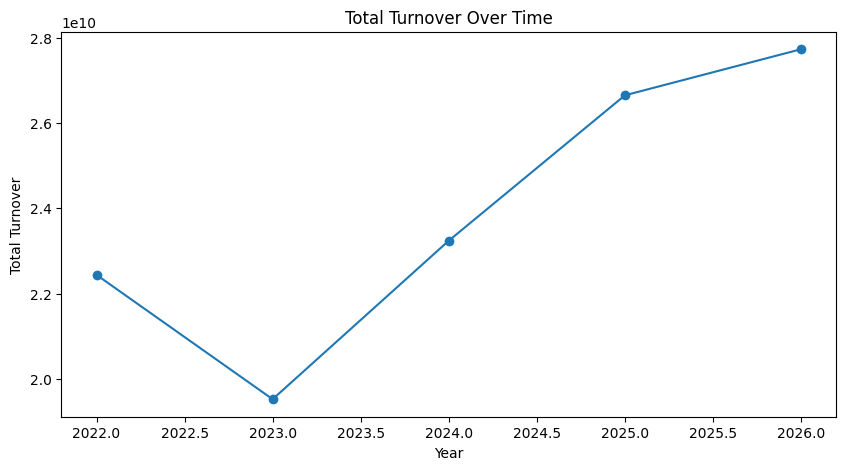

In [73]:
years = [2022, 2023, 2024, 2025, 2026]

plt.figure(figsize=(10, 5))

plt.plot(
    years,
    total_turnover.values,
    marker="o"
)

plt.title("Total Turnover Over Time")
plt.xlabel("Year")
plt.ylabel("Total Turnover")

plt.show()

What are we looking for?

Look for:

upward trends
downward trends
sudden increases
sudden decreases
unusual years

For this dataset, turnover drops in 2023 and then recovers from 2024 onward.

**Create a sector comparison chart**

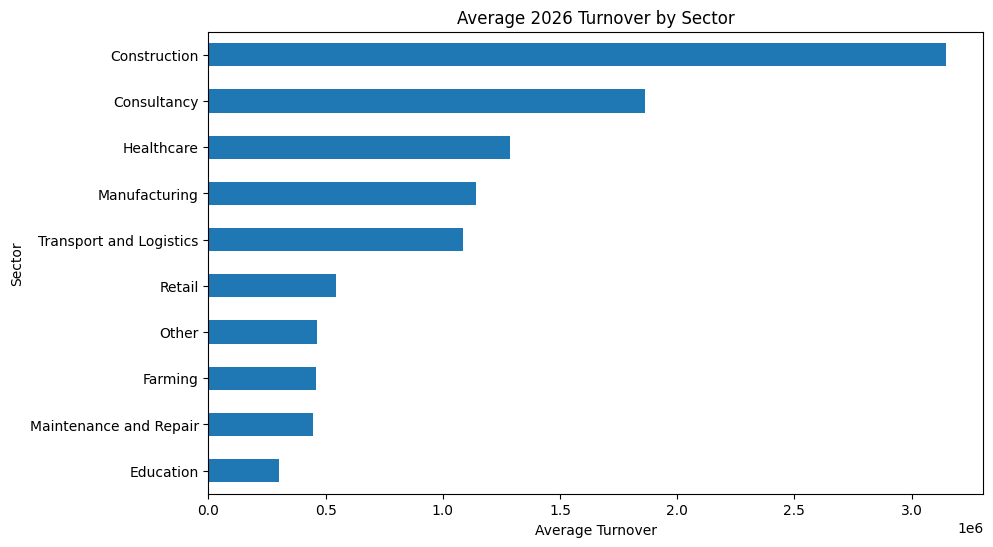

In [74]:
average_turnover.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Average 2026 Turnover by Sector")
plt.xlabel("Average Turnover")
plt.ylabel("Sector")

plt.show()

This makes it immediately obvious which sector has the highest average turnover.

Create an incorporation-month chart

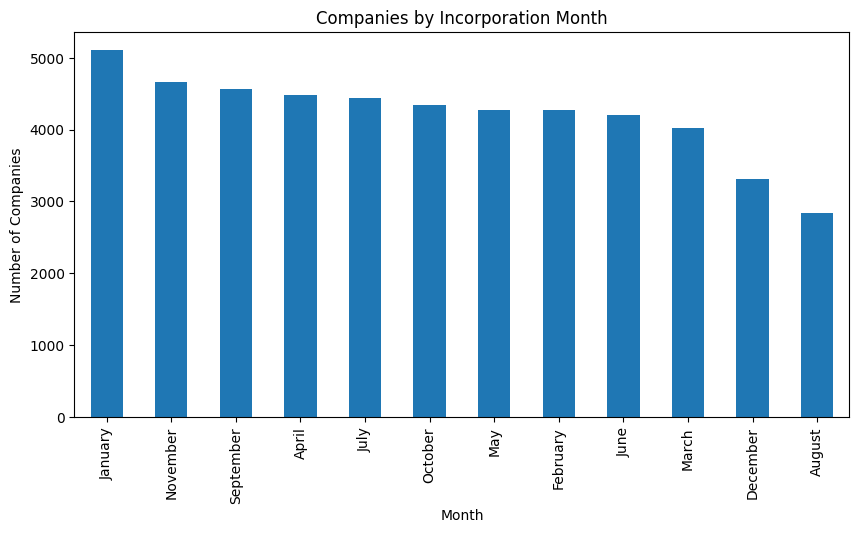

In [75]:
monthly_registrations.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Companies by Incorporation Month")
plt.xlabel("Month")
plt.ylabel("Number of Companies")

plt.show()

This visually demonstrates that January is the most common incorporation month.

** Your complete analysis workflow**

For your presentation, explain the process in this simple sequence:

EXCEL DATA
    ↓
Load data with Pandas
    ↓
Understand rows & columns
    ↓
Check data types
    ↓
Check missing values
    ↓
Check duplicates
    ↓
Identify summary rows
    ↓
Remove summary rows
    ↓
Convert dates
    ↓
Create Year & Month columns
    ↓
Check sectors
    ↓
Calculate company counts
    ↓
Calculate average turnover
    ↓
Calculate YoY turnover growth
    ↓
Measure consistency
    ↓
Analyse incorporation trends
    ↓
Analyse geographic trends
    ↓
Create charts
    ↓
Draw conclusions
The four questions and the Python methods
Assignment Question	Python method
Highest average turnover sector	groupby() + mean()
Sector with most companies	value_counts()
Most common incorporation month	value_counts()
Month by sector	crosstab()
Turnover over time	sum() / mean()
Year-on-year change	pct_change()
Most consistent sector	std()
Geographic comparison	groupby()
Geographic company concentration	value_counts()
Charts	matplotlib